<br>

<h1 style="text-align:center;">U-Net (Training)</h1>

<br>

## Introduction

---

In this section, we will perform the initial preparation of the code.

In [1]:
# Import the libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import glob
import os
import shutil
import numpy as np
from PIL import Image
import cv2
import tensorflow as tf
import keras.backend as K
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras.callbacks import EarlyStopping
from patchify import patchify, unpatchify

<br>

## Data Organization (Task 4)

---

In this section, we will transform the data repository from its raw format into a structured format suitable for segmentation tasks.

In [2]:
# TODO: Put this part inside the Task 4 folder

In [3]:
def create_directory_structure():
    """Create the required directory structure if it doesn't exist"""
    base_dir = 'dataset'
    subdirs = ['train_images/train', 'train_masks/train', 'val_images/val', 'val_masks/val']
    
    for subdir in subdirs:
        path = os.path.join(base_dir, subdir)
        os.makedirs(path, exist_ok=True)

In [4]:
def combine_masks(image_name, source_mask_dir):
    """Combine individual class masks into a single mask"""
    # Initialize empty mask
    mask = None
    
    # Load and combine masks for each class
    classes = ['root', 'shoot', 'seed']
    for i, class_name in enumerate(classes, start=1):
        mask_path = os.path.join(source_mask_dir, f"{image_name}_{class_name}_mask.tif")
        if os.path.exists(mask_path):
            class_mask = np.array(Image.open(mask_path))
            if mask is None:
                mask = np.zeros_like(class_mask)
            # Add class label (1, 2, or 3) where mask is True
            mask[class_mask > 0] = i
    
    return mask

In [5]:
def process_dataset():
    """Process and organize the dataset"""
    # Source directories
    raw_base = 'dataset raw/Y2B_23'
    
    # Process training data
    process_split('train', raw_base)
    
    # Process validation data (using test split)
    process_split('test', raw_base, dest_split='val')

In [6]:
def process_split(split, raw_base, dest_split=None):
    """Process a specific data split"""
    if dest_split is None:
        dest_split = split
        
    source_img_dir = os.path.join(raw_base, 'images', split)
    source_mask_dir = os.path.join(raw_base, 'masks')
    
    dest_img_dir = os.path.join('dataset', f'{dest_split}_images', dest_split)
    dest_mask_dir = os.path.join('dataset', f'{dest_split}_masks', dest_split)
    
    # Process each image in the split
    for img_name in os.listdir(source_img_dir):
        if img_name.endswith('.png'):

            # Copy image
            src_img_path = os.path.join(source_img_dir, img_name)
            dst_img_path = os.path.join(dest_img_dir, img_name)
            shutil.copy2(src_img_path, dst_img_path)
            
            # Process masks
            base_name = os.path.splitext(img_name)[0]
            combined_mask = combine_masks(base_name, source_mask_dir)
            
            if combined_mask is not None:
                # Save combined mask
                mask_path = os.path.join(dest_mask_dir, f"{base_name}.png")
                cv2.imwrite(mask_path, combined_mask)

In [7]:
# print("Creating directory structure...")
# create_directory_structure()

# print("Processing dataset...")
# process_dataset()

# print("Dataset organization complete!")

<br>

## Data Prepration

---

In this section, we will prepare the dataset for the modeling phase of the code.

In [8]:
# REQUIREMENT: Do not add code from Tasks 2 or 4
# REQUIREMENT: All dataset prep (crop/pad/patch/directory structure) must be finalize before attempting this task.

In [9]:
patch_size = 16*8
patch_dir = 'dataset_patched'
scaling_factor = 1

In [10]:
# Create a new directory for patches
# patch_dir = 'dataset_patched'
# for subdir in ['train_images/train', 'train_masks/train', 'val_images/val', 'val_masks/val']:
#     os.makedirs(os.path.join(patch_dir, subdir), exist_ok=True)

In [11]:
def padder(image, patch_size):
    """
    Adds padding to an image to make its dimensions divisible by a specified patch size.

    This function calculates the amount of padding needed for both the height and width of an image so that its dimensions become divisible by the given patch size. The padding is applied evenly to both sides of each dimension (top and bottom for height, left and right for width). If the padding amount is odd, one extra pixel is added to the bottom or right side. The padding color is set to black (0, 0, 0).

    Parameters:
    - image (numpy.ndarray): The input image as a NumPy array. Expected shape is (height, width, channels).
    - patch_size (int): The patch size to which the image dimensions should be divisible. It's applied to both height and width.

    Returns:
    - numpy.ndarray: The padded image as a NumPy array with the same number of channels as the input. Its dimensions are adjusted to be divisible by the specified patch size.

    Example:
    - padded_image = padder(cv2.imread('example.jpg'), 128)

    """
    h = image.shape[0]
    w = image.shape[1]
    height_padding = ((h // patch_size) + 1) * patch_size - h
    width_padding = ((w // patch_size) + 1) * patch_size - w

    top_padding = int(height_padding/2)
    bottom_padding = height_padding - top_padding

    left_padding = int(width_padding/2)
    right_padding = width_padding - left_padding

    padded_image = cv2.copyMakeBorder(image, top_padding, bottom_padding, left_padding, right_padding, cv2.BORDER_CONSTANT, value=[0, 0, 0])

    return padded_image

In [12]:
def create_and_save_patches(dataset_type, patch_size, scaling_factor):
    """
    Splits images and their corresponding masks from a blood cell dataset into smaller patches and saves them.

    This function takes images and masks from a specified dataset type, scales them if needed, and then splits them into smaller patches. Each patch is saved as a separate file. This is useful for preparing data for tasks like image segmentation in machine learning.

    Parameters:
    - dataset_type (str): The type of the dataset to process (e.g., 'train', 'test'). It expects a directory structure like 'blood_cell_dataset/{dataset_type}_images/{dataset_type}' for images and 'blood_cell_dataset/{dataset_type}_masks/{dataset_type}' for masks.
    - patch_size (int): The size of the patches to be created. Patches will be squares of size patch_size x patch_size.
    - scaling_factor (float): The factor by which the images and masks should be scaled. A value of 1 means no scaling.

    Returns:
    None. The function saves the patches as .png files in directories based on their original paths, but replacing 'blood_cell_dataset' with 'blood_cell_dataset_patched'.

    Note:
    - The function assumes a specific directory structure and naming convention for the dataset.
    """
    for image_path in glob.glob(f'dataset/{dataset_type}_images/{dataset_type}/*.png'):
        mask_path = image_path.replace('images', 'masks')

        image = cv2.imread(image_path)
        if image is None:
            print(f"Failed to load image: {image_path}")
            continue
        image = padder(image, patch_size)
        if scaling_factor != 1:
            image = cv2.resize(image, (0,0), fx=scaling_factor, fy=scaling_factor)
        patches = patchify(image, (patch_size, patch_size, 3), step=patch_size)
        patches = patches.reshape(-1, patch_size, patch_size, 3)

        image_patch_path = image_path.replace('dataset', patch_dir)
        for i, patch in enumerate(patches):
            image_patch_path_numbered = f'{image_patch_path[:-4]}_{i}.png'
            cv2.imwrite(image_patch_path_numbered, patch)

        mask_path = image_path.replace('image', 'mask')
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            print(f"Failed to load mask: {mask_path}")
            continue
        mask = padder(mask, patch_size)
        if scaling_factor != 1:
            mask = cv2.resize(mask, (0,0), fx=scaling_factor, fy=scaling_factor)
        patches = patchify(mask, (patch_size, patch_size), step=patch_size)
        patches = patches.reshape(-1, patch_size, patch_size, 1)

        mask_patch_path = mask_path.replace('dataset', patch_dir)
        for i, patch in enumerate(patches):
            mask_patch_path_numbered = f'{mask_patch_path[:-4]}_{i}.png'
            cv2.imwrite(mask_patch_path_numbered, patch)

In [13]:
# create_and_save_patches('train', patch_size, scaling_factor)
# create_and_save_patches('val', patch_size, scaling_factor)

In [14]:
# # Find the image dimensions

# # Load a sample image
# img = cv2.imread("./dataset/Y2B_23/images/train/000_43-2-ROOT1-2023-08-08_pvd_OD0001_f6h1_02-Fish Eye Corrected.png")

# # Get the dimensions
# height, width, channels = img.shape

# # Report
# print(f"Height: {height}, Width: {width}, Channels: {channels}")

In [15]:

def dataset_generator(dataset_type, patch_size, scaling_factor):
    """
    Generates a dataset of image patches and corresponding mask patches for segmentation tasks.

    This function reads images and their corresponding masks from a specified directory,
    scales them based on the provided scaling factor, and then splits them into patches of
    the specified size. It returns two numpy arrays containing the patches of the images and
    their corresponding masks.

    Args:
    - dataset_type (str): The type of dataset to process ('train', 'test', etc.), used to 
      determine the subdirectory within the blood cell dataset from which to load images.
    - patch_size (int): The height and width of the square patches to be extracted from each 
      image and mask. Assumes the images and masks are square.
    - scaling_factor (float): A factor to scale the images and masks. If it's different from 1,
      the images and masks are resized accordingly. A scaling factor greater than 1 enlarges 
      the images/masks, while a factor less than 1 shrinks them.

    Returns:
    - X (numpy.ndarray): An array of image patches. Each patch is a numpy array of shape 
      (patch_size, patch_size, 3), representing the height, width, and color channels.
    - y (numpy.ndarray): An array of corresponding mask patches. Each mask patch is a numpy 
      array of shape (patch_size, patch_size, 1), representing the height, width, and a single 
      channel for the mask.

    Note:
    - The function expects a directory structure with separate subdirectories for images and 
      masks within each dataset type (e.g., 'blood_cell_dataset/train_images/train/').
    - It uses OpenCV for image processing and assumes the mask images are grayscale.
    - The returned image and mask patches are normalized by dividing by 255.
    """
    X = []
    y = []
    
    # Get all image paths
    image_paths = glob.glob(f'./dataset/{dataset_type}_images/{dataset_type}/*.png')
    print(f"Found {len(image_paths)} images in {dataset_type} set")  # Debug print
    
    for image_path in image_paths:

      # Read image
      image = cv2.imread(image_path)
      if image is None:
          print(f"Failed to load image: {image_path}")
          continue

      # Read mask
      mask_path = image_path.replace('images', 'masks')
      mask = cv2.imread(mask_path, 0)
      if mask is None:
          print(f"Failed to load mask: {mask_path}")
          continue

      # Process the image
      image = padder(image, patch_size)
      if scaling_factor != 1:
          image = cv2.resize(image, (0,0), fx=scaling_factor, fy=scaling_factor)
      patches = patchify(image, (patch_size, patch_size, 3), step=patch_size)
      patches = patches.reshape(-1, patch_size, patch_size, 3)
      X.extend(patches)
        
      # Process the mask
      mask = padder(mask, patch_size)
      if scaling_factor != 1:
          mask = cv2.resize(mask, (0,0), fx=scaling_factor, fy=scaling_factor)
      patches = patchify(mask, (patch_size, patch_size), step=patch_size)
      patches = patches.reshape(-1, patch_size, patch_size, 1)
      y.extend(patches)
    
    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    # Print shapes for debugging
    print(f"{dataset_type} set shapes:")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    
    # Normalize
    X = X/255.0
    y = y/255.0

    # Use float16 instead of float32 to reduce memory usage
    X = X.astype('float16')
    y = (y > 0).astype('float32')  # Convert any positive values to 1
    
    return X, y

In [ ]:
X_train, y_train = dataset_generator(dataset_type='train',
                                     patch_size=patch_size,
                                     scaling_factor=scaling_factor)
X_train.shape, y_train.shape # ((4680, 128, 128, 3), (4680, 128, 128, 1))

Found 96 images in train set
Failed to load mask: ./dataset/train_masks/train\000_43-18-ROOT1-2023-08-08_pvdCherry_OD001_Col0_01-Fish Eye Corrected.png
Failed to load mask: ./dataset/train_masks/train\000_43-2-ROOT1-2023-08-08_pvd_OD0001_f6h1_02-Fish Eye Corrected.png
Failed to load mask: ./dataset/train_masks/train\008_43-17-ROOT1-2023-08-08_pvdCherry_OD001_Col0_01-Fish Eye Corrected.png
Failed to load mask: ./dataset/train_masks/train\008_43-2-ROOT1-2023-08-08_control_pH7_-Fe+B_col0_03-Fish Eye Corrected.png
Failed to load mask: ./dataset/train_masks/train\019_43-19-ROOT1-2023-08-08_pvd_OD001_Col0_03-Fish Eye Corrected.png
Failed to load mask: ./dataset/train_masks/train\019_43-6-ROOT1-2023-08-08_control_pH7_-Fe+B_col0_01-Fish Eye Corrected.png
Failed to load mask: ./dataset/train_masks/train\023_43-14-ROOT1-2023-08-08_pvdCherry_OD0001_f6h1_03-Fish Eye Corrected.png
Failed to load mask: ./dataset/train_masks/train\023_43-18-ROOT1-2023-08-08_pvd_OD001_f6h1_01-Fish Eye Corrected.png
tr

In [17]:
X_val, y_val = dataset_generator(dataset_type='val',
                                 patch_size=patch_size,
                                 scaling_factor=scaling_factor)
X_val.shape, y_val.shape # ((520, 128, 128, 3), (520, 128, 128, 1))

Found 30 images in val set
Failed to load mask: ./dataset/val_masks/val\037_43-11-ROOT1-2023-08-08_mock_pH5_f6h1_01-Fish Eye Corrected.png
Failed to load mask: ./dataset/val_masks/val\037_43-14-ROOT1-2023-08-08_mock_pH5_+Fe_Col0_04-Fish Eye Corrected.png
Failed to load mask: ./dataset/val_masks/val\037_43-18-ROOT1-2023-08-08_mock_pH5_+Fe_Col0_04-Fish Eye Corrected.png
val set shapes:
X shape: (21384, 128, 128, 3)
y shape: (21384, 128, 128, 1)


((21384, 128, 128, 3), (21384, 128, 128, 1))

In [18]:
# Add this before training to verify data
def check_data(X, y):
    print("X shape:", X.shape)
    print("X min/max:", X.min(), X.max())
    print("y shape:", y.shape)
    print("y unique values:", np.unique(y))
    print("y distribution:", np.mean(y))

# Check both training and validation data
print("Training data:")
check_data(X_train, y_train)
print("\nValidation data:")
check_data(X_val, y_val)

Training data:
X shape: (69696, 128, 128, 3)
X min/max: 0.0 1.0
y shape: (69696, 128, 128, 1)
y unique values: [0. 1.]
y distribution: 0.009751466

Validation data:
X shape: (21384, 128, 128, 3)
X min/max: 0.0 1.0
y shape: (21384, 128, 128, 1)
y unique values: [0. 1.]
y distribution: 0.008438864


<br>

## Helper Functions

---

In [19]:
def f1(y_true, y_pred):
    """
    Calculate F1 score. If there are no True Positives, the score is 0.
    """
    # Threshold predictions to get binary values
    y_pred = tf.cast(tf.greater(y_pred, 0.5), tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    
    # Calculate True Positives, False Positives, False Negatives
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    
    # Calculate precision and recall
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    
    # Calculate F1
    f1_score = 2 * (precision * recall) / (precision + recall + K.epsilon())
    
    return f1_score

<br>

## Modeling

---

In [20]:
# U-Net model
def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):

    # Ensure input dimensions are divisible by 16
    if IMG_HEIGHT % 16 != 0 or IMG_WIDTH % 16 != 0:
        raise ValueError(f"Height ({IMG_HEIGHT}) and width ({IMG_WIDTH}) must be divisible by 16")

    # Build the model
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = inputs

    # Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
     
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
     
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
     
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    # Expansive path 
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
     
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
     
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
     
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
     
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
     
    model = Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', f1])
    model.summary()
    
    return model

In [21]:
# Build U-Net
# REQUIREMENT: Model summary must be visible
# model = simple_unet_model(patch_size, patch_size, 3)

In [22]:
from tensorflow.keras.layers import *

def unet(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    """
    High-performance U-Net implementation with:
    - Residual connections
    - Instance normalization
    - LeakyReLU activation
    - Deeper architecture
    """
    if IMG_HEIGHT % 16 != 0 or IMG_WIDTH % 16 != 0:
        raise ValueError(f"Height ({IMG_HEIGHT}) and width ({IMG_WIDTH}) must be divisible by 16")

    def conv_block(inputs, filters, dropout_rate=0.0):
        x = Conv2D(filters, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha=0.1)(x)
        x = Dropout(dropout_rate)(x)
        
        x = Conv2D(filters, (3, 3), padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha=0.1)(x)
        
        # Residual connection
        shortcut = Conv2D(filters, (1, 1), padding='same')(inputs)
        x = Add()([shortcut, x])
        return x

    # Input
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    
    # Initial processing
    x = Conv2D(32, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)

    # Encoder path
    skip1 = conv_block(x, 64, 0.1)
    p1 = MaxPooling2D((2, 2))(skip1)
    
    skip2 = conv_block(p1, 128, 0.1)
    p2 = MaxPooling2D((2, 2))(skip2)
    
    skip3 = conv_block(p2, 256, 0.2)
    p3 = MaxPooling2D((2, 2))(skip3)
    
    skip4 = conv_block(p3, 512, 0.2)
    p4 = MaxPooling2D((2, 2))(skip4)

    # Bridge
    bridge = conv_block(p4, 1024, 0.3)

    # Decoder path
    u6 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(bridge)
    u6 = concatenate([u6, skip4])
    c6 = conv_block(u6, 512, 0.2)
    
    u7 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, skip3])
    c7 = conv_block(u7, 256, 0.2)
    
    u8 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, skip2])
    c8 = conv_block(u8, 128, 0.1)
    
    u9 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, skip1])
    c9 = conv_block(u9, 64, 0.1)

    # Output
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    
    # Model compilation
    model = Model(inputs=[inputs], outputs=[outputs])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', f1]
    )

    # Model summary
    model.summary()
    
    return model

In [23]:
model = unet(patch_size, patch_size, 3)

c:\Users\Soheil\.conda\envs\FireFury\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     18,496 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ leaky_re_lu_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     36,928 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      2,112 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ conv2d_3[0][0],   │
│                     │ 64)               │            │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 32,470,657 (123.87 MB)

 Trainable params: 32,458,817 (123.82 MB)

 Non-trainable params: 11,840 (46.25 KB)

<br>

## Training

---

In [ ]:
# Early stopping callback
cb = EarlyStopping(
    monitor='val_f1',
    patience=5,
    restore_best_weights=True,
    mode='max'  # We want to maximize F1
)

In [ ]:
# This is where the magic happens
# REQUIREMENT: The epoch logs must be visible showing validation loss and validation f1.
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20, 
    validation_data=(X_val, y_val),
    callbacks=[cb]
)

Epoch 1/20


c:\Users\Soheil\.conda\envs\FireFury\lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


  5/545 ━━━━━━━━━━━━━━━━━━━━ 4:48:03 32s/step - accuracy: 0.8042 - f1: 0.0062 - loss: 0.4225

In [ ]:
# REQUIREMENT: Save your model, it is a deliverable
# REQUIREMENT: naming convention 'studentname_studentnumber_unet_model_patchsizepx.h5'
example_file_name = f'soheil_6989490_unet_model_{patch_size}px.h5'
print(example_file_name)
model.save(example_file_name)

In [ ]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
best_val_loss = min(history.history['val_loss'])
best_val_f1 = max(history.history['val_f1'])
print(f"Best validation loss: {best_val_loss}")
print(f"Best validation f1: {best_val_f1}")

Best validation loss: 0.004732396919280291
Best validation f1: 0.8092314600944519


<br>

## Evaluation

---

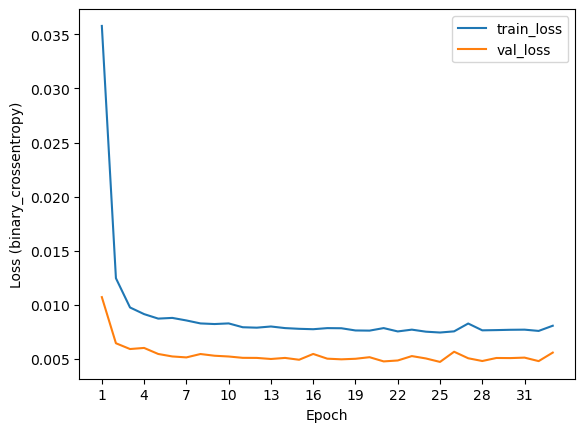

In [ ]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(loss) + 1)

plt.plot(epochs, loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (binary_crossentropy)')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))

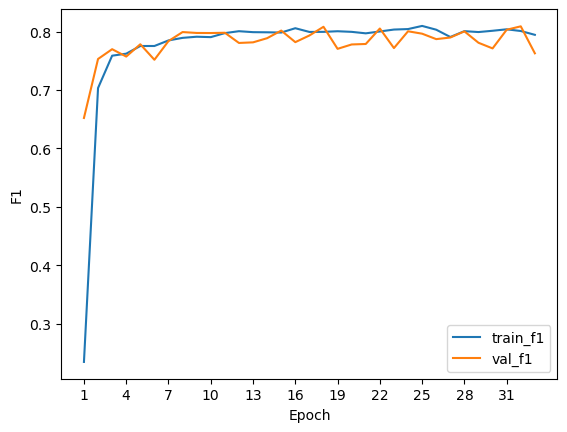

In [ ]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
train_f1 = history.history['f1']
val_f1 = history.history['val_f1']

epochs = np.arange(1, len(train_f1) + 1)

plt.plot(epochs, train_f1, label='train_f1')
plt.plot(epochs, val_f1, label='val_f1')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('F1')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))